1) Load the dataset,
2) Features = A, B, C, D - Target = E (binary classifier) 
3) Logistics Regression, Naive Bayes, KNN, SVM 
4) Accuracies for all the models.
5) Which model is best. Apply GridSearchCV 
6) Do hyperparameter tuning. 
7) Again training the model based on best parametsrs

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

#from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



In [3]:
df=pd.read_csv(r"C:\Users\Gopal Chavan\Downloads\Social_Network_Ads.csv.xls")


In [4]:
# # Load Dataset
# drive.mount('/content/drive')
# import os

# file_path = "/content/drive/MyDrive/Social_Network_Ads.csv.xls"

# print(os.path.exists(file_path))

In [5]:
# import pandas as pd

# df = pd.read_csv(file_path)

# df.head()

In [6]:
print(df.head())
print(df.info())
print(df.isnull().sum())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [7]:
# Label Encoding

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [8]:
# Features and Target

X = df[["User ID","Gender","Age","EstimatedSalary"]]

y = df["Purchased"]

In [9]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
# Logistic Regression


df=pd.read_csv(r"C:\Users\Gopal Chavan\Downloads\Social_Network_Ads.csv.xls")
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

#Best Parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}



lr = LogisticRegression( C= 0.1,
    penalty= 'l2' ,
    solver= 'liblinear',
    max_iter= 1000,
    class_weight=None)



lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("\nLogistic Regression Accuracy :", acc_lr)


Logistic Regression Accuracy : 0.8875


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score



In [13]:

# Hyperparameter Grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'saga'],
    'max_iter': [100, 200, 500, 1000]
}

# Grid Search
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


In [14]:
print(hasattr(grid_lr, "best_params_"))

False


In [15]:
grid_lr.fit(X_train, y_train)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(C=0.1, max_iter=1000,
                                          solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 200, 500, 1000], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'saga']},
             scoring='accuracy', verbose=2)

In [16]:

# Best Parameters
print("Best Parameters:", grid_lr.best_params_)
print("Best Cross Validation Score:", grid_lr.best_score_)


Best Parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross Validation Score: 0.81875


In [17]:
print(grid_lr.best_params_)

{'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [18]:
# Naive Bayes

nb = GaussianNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy :", acc_nb)

Naive Bayes Accuracy : 0.9125


In [19]:
# KNN

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy :", acc_knn)

KNN Accuracy : 0.925


In [20]:
# SVM

svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy :", acc_svm)

SVM Accuracy : 0.925


In [21]:
# Accuracy Comparison

result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "SVM"
    ],
    "Accuracy":[
        acc_lr,
        acc_nb,
        acc_knn,
        acc_svm
    ]
})

In [22]:
print("\nModel Comparison")
print(result)

best_model = result.loc[result["Accuracy"].idxmax()]

print("\nBest Model")
print(best_model)


Model Comparison
                 Model  Accuracy
0  Logistic Regression    0.8875
1          Naive Bayes    0.9125
2                  KNN    0.9250
3                  SVM    0.9250

Best Model
Model         KNN
Accuracy    0.925
Name: 2, dtype: object


In [23]:
# Grid Search (SVM)

param_grid = {
    "C":[0.1,1,10,100],
    "kernel":["linear","rbf"],
    "gamma":["scale","auto"]
}

grid = GridSearchCV(
    SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("\nBest Parameters")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(grid.best_score_)


Best Parameters
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Accuracy
0.90625


In [24]:
# Grid Search (Logistic Regression)

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

print("\nBest Parameters (Logistic Regression)")
print(grid_lr.best_params_)

print("\nBest Cross Validation Accuracy (Logistic Regression)")
print(grid_lr.best_score_)


Best Parameters (Logistic Regression)
{'C': 0.01, 'solver': 'liblinear'}

Best Cross Validation Accuracy (Logistic Regression)
0.81875


In [25]:
# Grid Search (Naive Bayes)

# Naive Bayes generally does not have hyper-parameters to tune in the same way other models do.
# However, for GaussianNB, sometimes 'var_smoothing' can be tuned.
param_grid_nb = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid=param_grid_nb,
    cv=5,
    scoring='accuracy'
)

grid_nb.fit(X_train, y_train)

print("\nBest Parameters (Naive Bayes)")
print(grid_nb.best_params_)

print("\nBest Cross Validation Accuracy (Naive Bayes)")
print(grid_nb.best_score_)


Best Parameters (Naive Bayes)
{'var_smoothing': 0.0023101297000831605}

Best Cross Validation Accuracy (Naive Bayes)
0.8625


In [26]:
# Grid Search (KNN)

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train, y_train)

print("\nBest Parameters (KNN)")
print(grid_knn.best_params_)

print("\nBest Cross Validation Accuracy (KNN)")
print(grid_knn.best_score_)


Best Parameters (KNN)
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

Best Cross Validation Accuracy (KNN)
0.896875


In [27]:
# Re-evaluating the SVM Grid Search to ensure 'grid' is available if the user runs cells out of order.
param_grid_svm = {
    "C":[0.1,1,10,100],
    "kernel":["linear","rbf"],
    "gamma":["scale","auto"]
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [28]:
# Accuracy Score

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, final_prediction)

print("Accuracy :", accuracy)

NameError: name 'final_prediction' is not defined

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_prediction)

print(cm)

[[48  4]
 [ 2 26]]


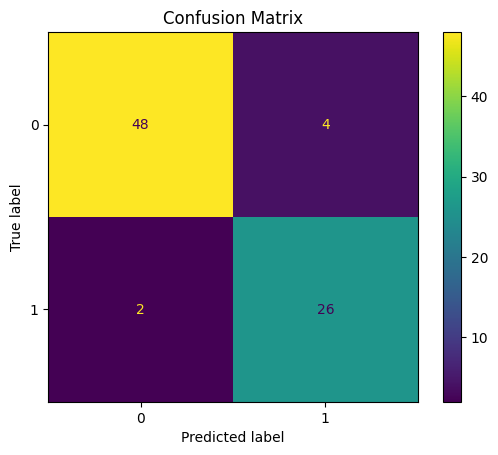

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, final_prediction)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, final_prediction))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
        

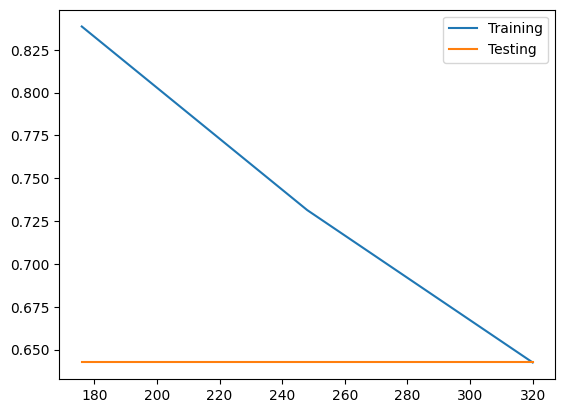

In [ ]:
# Learning Curve

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_size, train_score, test_score = learning_curve(
    SVC(),
    X,
    y,
    cv=5
)

plt.plot(train_size, train_score.mean(axis=1), label="Training")

plt.plot(train_size, test_score.mean(axis=1), label="Testing")

plt.legend()

plt.show()


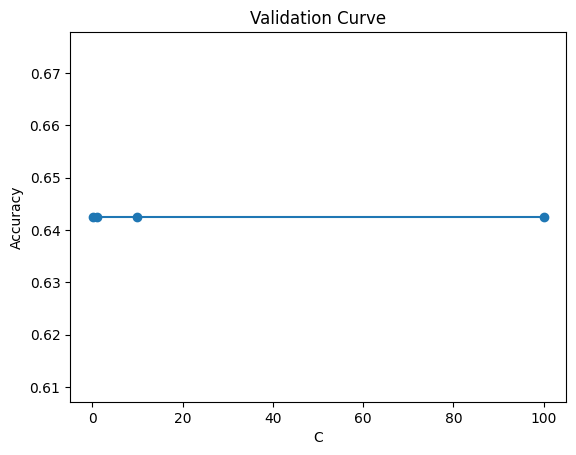

In [ ]:
# Validation Curve(Hyperparameter Tuning)

from sklearn.model_selection import validation_curve

param_range = [0.1,1,10,100]

train_score, test_score = validation_curve(
    SVC(kernel='rbf'),
    X,
    y,
    param_name="C",
    param_range=param_range,
    cv=5
)

plt.plot(param_range, test_score.mean(axis=1), marker='o')

plt.xlabel("C")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.show()

In [ ]:
# Final Model

final_model = SVC(
    C=grid.best_params_["C"],
    kernel=grid.best_params_["kernel"],
    gamma=grid.best_params_["gamma"]
)

final_model.fit(X_train, y_train)

final_prediction = final_model.predict(X_test)

print("\nFinal Accuracy")
print(accuracy_score(y_test, final_prediction))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_prediction))

print("\nClassification Report")
print(classification_report(y_test, final_prediction))


Final Accuracy
0.925

Confusion Matrix
[[48  4]
 [ 2 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



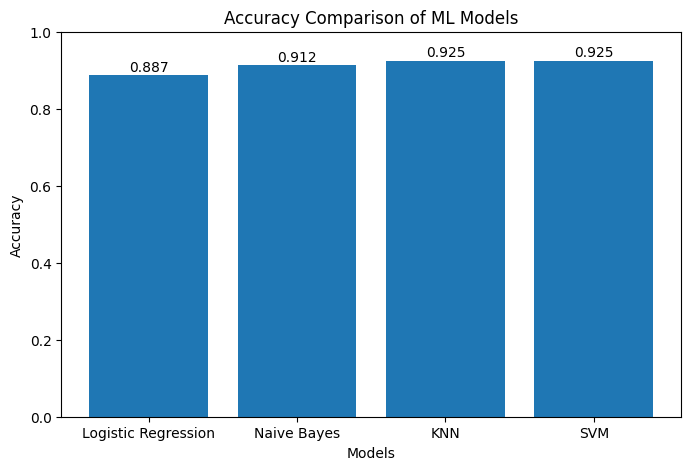

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values
models = ['Logistic Regression', 'Naive Bayes', 'KNN', 'SVM']

accuracy = [acc_lr, acc_nb, acc_knn, acc_svm]

# Plot graph
plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Accuracy Comparison of ML Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

# Show accuracy value on bars
for i in range(len(models)):
    plt.text(i, accuracy[i]+0.01, round(accuracy[i],3), ha='center')

plt.show()

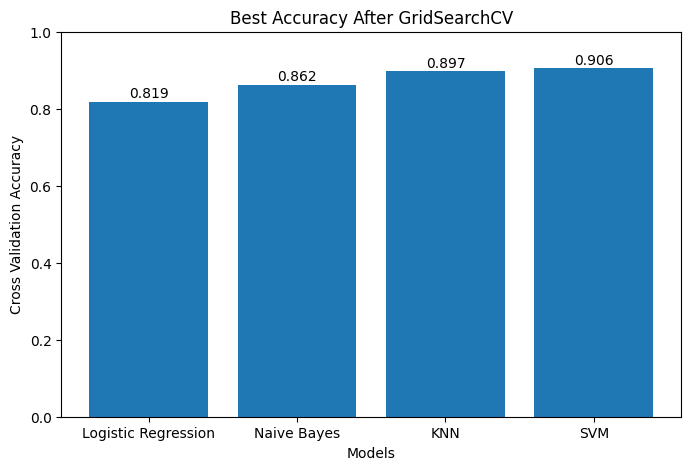

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes', 'KNN', 'SVM']

best_accuracy = [
    grid_lr.best_score_,
    grid_nb.best_score_,
    grid_knn.best_score_,
    grid_svm.best_score_
]

plt.figure(figsize=(8,5))

plt.bar(models, best_accuracy)

plt.title("Best Accuracy After GridSearchCV")

plt.xlabel("Models")

plt.ylabel("Cross Validation Accuracy")

plt.ylim(0,1)

for i in range(len(models)):
    plt.text(i, best_accuracy[i]+0.01, round(best_accuracy[i],3), ha='center')

plt.show()

In [ ]:
best_index = best_accuracy.index(max(best_accuracy))

print("Best Model :", models[best_index])

print("Best Accuracy :", best_accuracy[best_index])

Best Model : SVM
Best Accuracy : 0.90625
